# MNIST Denoising Autoencoder (PyTorch)

**Project 1 — Week 6 Assessment**

This notebook follows the structure of the reference repo
[`NvsYashwanth/MNIST-Autoecncoder`](https://github.com/NvsYashwanth/MNIST-Autoecncoder)
— same **PyTorch** framework, the same **three autoencoder variants** (FFNN, transpose-CNN,
upsampled-CNN), the same **MSE loss**, the same **48,000 / 12,000 train-validation split**,
and **20 epochs** — but adapted to the **denoising** task this assignment asks for.

**Reconstruction vs. denoising:** the reference repo trains each model to copy its input to
its output (`loss = MSE(output, input)`). For denoising we change one thing: we feed the
model a **noisy** image and ask it to reproduce the **clean** original
(`loss = MSE(output, clean)`). Everything else — architecture, loss, training loop — is the
same. The bottleneck can't encode random noise, so the network learns to keep only the digit.

**Models built here**
1. **FFNN autoencoder** — images flattened to 784-length vectors, linear encoder/decoder.
2. **Transpose-CNN autoencoder** — convolutional encoder, `ConvTranspose2d` decoder.
3. **Upsampled-CNN autoencoder** — nearest-neighbour upsampling + conv decoder (avoids the
   checkerboard artifacts that transpose convolutions can produce).


## 1. Imports and device setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Using device   :", device)


PyTorch version: 2.11.0+cu128
Using device   : cuda


## 2. Load MNIST and make the 48k / 12k / 10k split

`torchvision` downloads MNIST automatically. Following the repo, we carve a **12,000-image
validation set** out of the 60,000 training images, leaving **48,000** for training. The
10,000 test images are kept separate.

> **On Kaggle / using the dataset link?** If you'd rather load the Kaggle CSV files
> (`awsaf49/mnist-dataset`), read them into tensors of shape `(N, 1, 28, 28)` scaled to
> `[0, 1]` and wrap them in a `TensorDataset`. A commented example is at the end of this cell.

In [2]:
transform = transforms.ToTensor()  # converts to FloatTensor in [0, 1], shape (1, 28, 28)

full_train = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_set   = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# 60,000 -> 48,000 train + 12,000 validation
train_set, val_set = random_split(full_train, [48000, 12000],
                                  generator=torch.Generator().manual_seed(SEED))

BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

# --- Kaggle CSV alternative (uncomment if needed) ---
# import pandas as pd
# from torch.utils.data import TensorDataset
# df = pd.read_csv("/kaggle/input/mnist-dataset/mnist_train.csv")
# imgs = torch.tensor(df.iloc[:, 1:].values, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0
# full_train = TensorDataset(imgs, torch.zeros(len(imgs)))   # labels unused


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.05MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.09MB/s]

Train: 48000 | Val: 12000 | Test: 10000


## 3. The denoising helper

This is the only conceptual change from the reconstruction repo: a function that adds
**Gaussian noise** to a batch and clips it back to `[0, 1]`. During training the *noisy*
tensor is the input and the *clean* tensor is the target.

`noisy = clean + noise_factor * N(0, 1)`

In [3]:
NOISE_FACTOR = 0.5

def add_noise(imgs, noise_factor=NOISE_FACTOR):
    noisy = imgs + noise_factor * torch.randn_like(imgs)
    return torch.clamp(noisy, 0.0, 1.0)


### Preview: clean vs. noisy

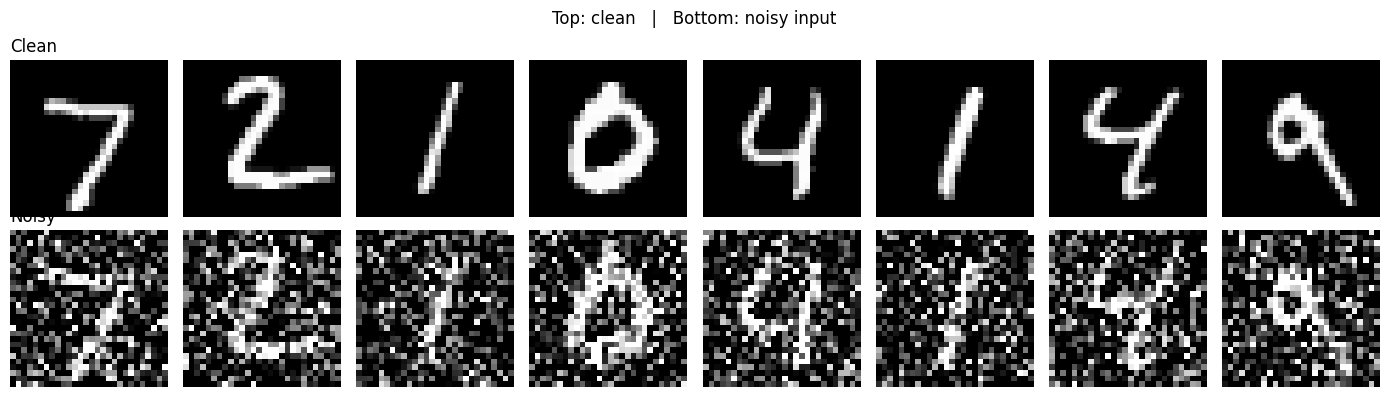

In [4]:
sample_imgs, _ = next(iter(test_loader))
sample_noisy = add_noise(sample_imgs)

n = 8
plt.figure(figsize=(14, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(sample_imgs[i].squeeze(), cmap="gray"); plt.axis("off")
    if i == 0: ax.set_title("Clean", loc="left")
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(sample_noisy[i].squeeze(), cmap="gray"); plt.axis("off")
    if i == 0: ax.set_title("Noisy", loc="left")
plt.suptitle("Top: clean   |   Bottom: noisy input"); plt.tight_layout(); plt.show()


## 4. Weight initialisation (as in the repo)

The reference repo initialises the **Linear** layers with weights sampled from a normal
distribution with standard deviation `y = 1 / sqrt(n)` (where `n` is the number of input
nodes) and biases set to `0`. Values near zero are more likely than large ones, which helps
training start stably. We apply the same scheme.

In [5]:
def init_linear_weights(module):
    if isinstance(module, nn.Linear):
        n = module.in_features
        y = 1.0 / np.sqrt(n)
        nn.init.normal_(module.weight, mean=0.0, std=y)
        nn.init.zeros_(module.bias)


## 5. Model 1 — FFNN (fully-connected) autoencoder

Images are flattened to 784-length vectors. A single linear layer compresses to a small
**encoding dimension**, and a single linear layer expands back to 784. A `sigmoid` on the
output keeps pixels in `[0, 1]`.

In [6]:
class FFNNAutoencoder(nn.Module):
    def __init__(self, encoding_dim=32):
        super().__init__()
        self.encoder = nn.Linear(28 * 28, encoding_dim)
        self.decoder = nn.Linear(encoding_dim, 28 * 28)

    def forward(self, x):
        x = x.view(x.size(0), -1)          # flatten -> (batch, 784)
        x = F.relu(self.encoder(x))        # compressed representation
        x = torch.sigmoid(self.decoder(x)) # reconstruct -> (batch, 784)
        return x.view(x.size(0), 1, 28, 28)


## 6. Model 2 — Transpose-CNN autoencoder

A convolutional encoder downsamples to a **7×7×4** bottleneck (196 values ≈ 25% of the
original 784). The decoder uses `ConvTranspose2d` layers to upsample back to 28×28×1.

In [7]:
class TransposeConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: 28x28x1 -> 14x14x16 -> 7x7x4
        self.enc_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.enc_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # Decoder: 7x7x4 -> 14x14x16 -> 28x28x1
        self.dec_tconv1 = nn.ConvTranspose2d(4, 16, 2, stride=2)
        self.dec_tconv2 = nn.ConvTranspose2d(16, 1, 2, stride=2)

    def forward(self, x):
        x = self.pool(F.relu(self.enc_conv1(x)))   # 14x14x16
        x = self.pool(F.relu(self.enc_conv2(x)))   # 7x7x4 (bottleneck)
        x = F.relu(self.dec_tconv1(x))             # 14x14x16
        x = torch.sigmoid(self.dec_tconv2(x))      # 28x28x1
        return x


## 7. Model 3 — Upsampled-CNN autoencoder

Same encoder as Model 2. The decoder replaces transposed convolutions with
**nearest-neighbour upsampling followed by an ordinary convolution**. This avoids the
checkerboard artifacts that transpose convolutions can introduce when kernel and stride
overlap.

In [8]:
class UpsampleConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder (same as Model 2)
        self.enc_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.enc_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # Decoder: upsample + conv
        self.dec_conv1 = nn.Conv2d(4, 16, 3, padding=1)
        self.dec_conv2 = nn.Conv2d(16, 1, 3, padding=1)

    def forward(self, x):
        x = self.pool(F.relu(self.enc_conv1(x)))   # 14x14x16
        x = self.pool(F.relu(self.enc_conv2(x)))   # 7x7x4 (bottleneck)
        x = F.interpolate(x, scale_factor=2, mode="nearest")  # 14x14
        x = F.relu(self.dec_conv1(x))
        x = F.interpolate(x, scale_factor=2, mode="nearest")  # 28x28
        x = torch.sigmoid(self.dec_conv2(x))
        return x


## 8. Training loop

Reusable for all three models. The key denoising step is inside the loop: we noise the batch
and compare the model's output against the **clean** images using **MSE loss** (the same loss
the repo uses for reconstruction).

In [9]:
EPOCHS = 20

def train_model(model, name, epochs=EPOCHS, lr=1e-3):
    model = model.to(device)
    model.apply(init_linear_weights)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train": [], "val": []}
    for epoch in range(1, epochs + 1):
        # ---- training ----
        model.train()
        train_loss = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            noisy = add_noise(imgs)
            optimizer.zero_grad()
            outputs = model(noisy)
            loss = criterion(outputs, imgs)     # noisy in -> clean target
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
        train_loss /= len(train_loader.dataset)

        # ---- validation ----
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                noisy = add_noise(imgs)
                outputs = model(noisy)
                val_loss += criterion(outputs, imgs).item() * imgs.size(0)
        val_loss /= len(val_loader.dataset)

        history["train"].append(train_loss)
        history["val"].append(val_loss)
        print(f"[{name}] Epoch {epoch:2d}/{epochs}  train {train_loss:.4f}  val {val_loss:.4f}")

    return model, history


### Train all three models

On a GPU each model takes a couple of minutes. On CPU, lower `EPOCHS` if needed.

In [10]:
ffnn_model,  ffnn_hist  = train_model(FFNNAutoencoder(),          "FFNN")
tconv_model, tconv_hist = train_model(TransposeConvAutoencoder(), "TransposeCNN")
upsamp_model, upsamp_hist = train_model(UpsampleConvAutoencoder(), "UpsampleCNN")


[FFNN] Epoch  1/20  train 0.0660  val 0.0439
[FFNN] Epoch  2/20  train 0.0389  val 0.0355
[FFNN] Epoch  3/20  train 0.0340  val 0.0326
[FFNN] Epoch  4/20  train 0.0318  val 0.0311
[FFNN] Epoch  5/20  train 0.0308  val 0.0304
[FFNN] Epoch  6/20  train 0.0302  val 0.0300
[FFNN] Epoch  7/20  train 0.0300  val 0.0298
[FFNN] Epoch  8/20  train 0.0298  val 0.0297
[FFNN] Epoch  9/20  train 0.0296  val 0.0296
[FFNN] Epoch 10/20  train 0.0296  val 0.0295
[FFNN] Epoch 11/20  train 0.0295  val 0.0294
[FFNN] Epoch 12/20  train 0.0294  val 0.0294
[FFNN] Epoch 13/20  train 0.0293  val 0.0293
[FFNN] Epoch 14/20  train 0.0293  val 0.0292
[FFNN] Epoch 15/20  train 0.0292  val 0.0291
[FFNN] Epoch 16/20  train 0.0292  val 0.0291
[FFNN] Epoch 17/20  train 0.0291  val 0.0291
[FFNN] Epoch 18/20  train 0.0290  val 0.0289
[FFNN] Epoch 19/20  train 0.0289  val 0.0289
[FFNN] Epoch 20/20  train 0.0289  val 0.0288
[TransposeCNN] Epoch  1/20  train 0.0823  val 0.0386
[TransposeCNN] Epoch  2/20  train 0.0309  val 0

## 9. Save the trained weights

The repo ships saved weights (`F_Auto_MNIST_model.pth`, `Tran_conv_Auto_MNIST_model.pth`,
`upsamp_conv_Auto_MNIST_model.pth`). We save ours with matching names.

In [11]:
torch.save(ffnn_model.state_dict(),  "F_Auto_MNIST_model.pth")
torch.save(tconv_model.state_dict(),  "Tran_conv_Auto_MNIST_model.pth")
torch.save(upsamp_model.state_dict(), "upsamp_conv_Auto_MNIST_model.pth")
print("Saved model weights.")


Saved model weights.


## 10. Loss curves

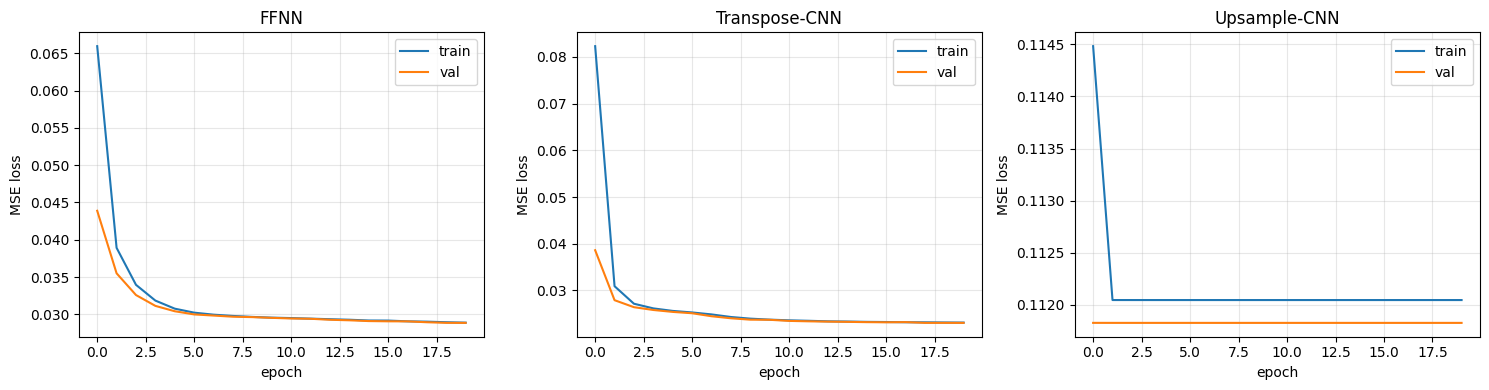

In [12]:
plt.figure(figsize=(15, 4))
for i, (name, h) in enumerate([("FFNN", ffnn_hist),
                               ("Transpose-CNN", tconv_hist),
                               ("Upsample-CNN", upsamp_hist)], 1):
    plt.subplot(1, 3, i)
    plt.plot(h["train"], label="train")
    plt.plot(h["val"], label="val")
    plt.title(name); plt.xlabel("epoch"); plt.ylabel("MSE loss")
    plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 11. Denoising results — compare the three models

Rows: noisy input, then each model's denoised output, then the clean original.

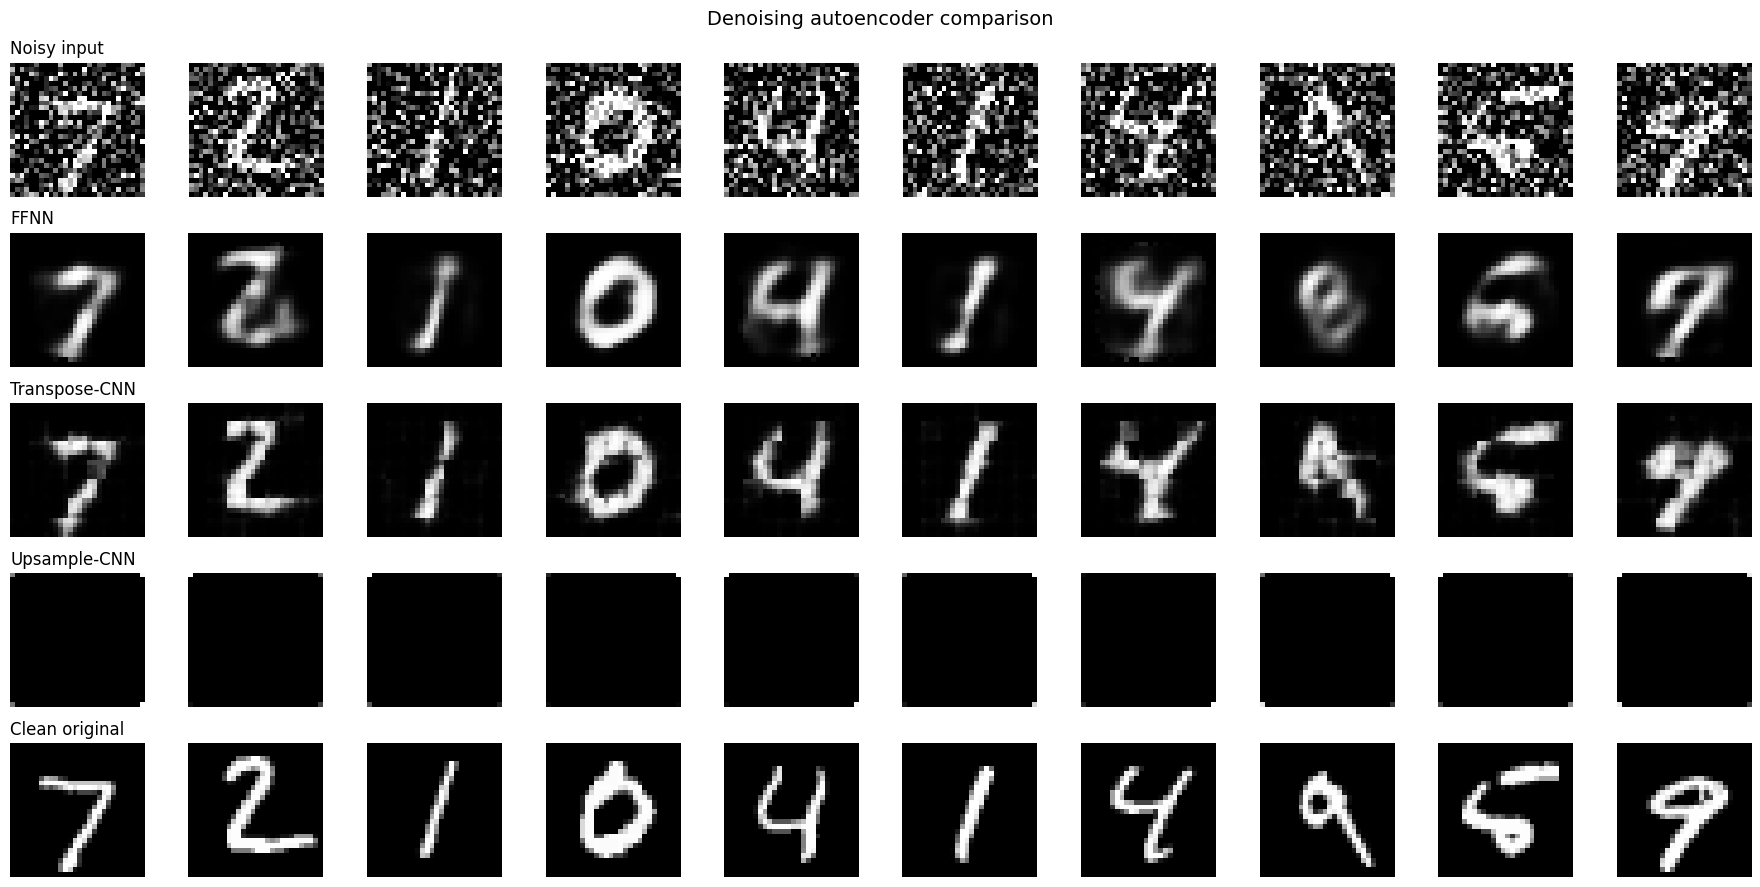

In [13]:
test_imgs, _ = next(iter(test_loader))
test_imgs = test_imgs.to(device)
test_noisy = add_noise(test_imgs)

def denoise(model):
    model.eval()
    with torch.no_grad():
        return model(test_noisy).cpu()

out_ffnn   = denoise(ffnn_model)
out_tconv  = denoise(tconv_model)
out_upsamp = denoise(upsamp_model)

rows = [
    ("Noisy input",      test_noisy.cpu()),
    ("FFNN",             out_ffnn),
    ("Transpose-CNN",    out_tconv),
    ("Upsample-CNN",     out_upsamp),
    ("Clean original",   test_imgs.cpu()),
]

n = 10
plt.figure(figsize=(18, 9))
for r, (label, batch) in enumerate(rows):
    for i in range(n):
        ax = plt.subplot(len(rows), n, r * n + i + 1)
        plt.imshow(batch[i].squeeze(), cmap="gray"); plt.axis("off")
        if i == 0: ax.set_title(label, loc="left")
plt.suptitle("Denoising autoencoder comparison", fontsize=14)
plt.tight_layout(); plt.show()


## 12. Quantitative check — PSNR

Higher PSNR (dB) means the output is closer to the clean original. We compare the noisy
baseline against each model on a batch of test images.

In [14]:
def psnr(a, b):
    mse = torch.mean((a - b) ** 2).item()
    return float("inf") if mse == 0 else 20 * np.log10(1.0 / np.sqrt(mse))

clean = test_imgs.cpu()
print(f"Noisy baseline   : {psnr(clean, test_noisy.cpu()):.2f} dB")
print(f"FFNN             : {psnr(clean, out_ffnn):.2f} dB")
print(f"Transpose-CNN    : {psnr(clean, out_tconv):.2f} dB")
print(f"Upsample-CNN     : {psnr(clean, out_upsamp):.2f} dB")


Noisy baseline   : 9.39 dB
FFNN             : 15.36 dB
Transpose-CNN    : 16.54 dB
Upsample-CNN     : 10.14 dB
